<a href="https://colab.research.google.com/github/simply-logical/mlbook_ii_notebooks/blob/master/Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# simplex demo

In [ ]:
# import Python packages
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.svm import SVC

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
%matplotlib inline

In [ ]:
# import bespoke simplex module
from simplex import SimplexColormap, plot_decision_regions, simplex_legend

In [ ]:
data = load_iris(as_frame=True)
samples = [10, 25, 50]
data.target[samples]
data.target_names[data.target[samples]]

array(['setosa', 'setosa', 'versicolor'], dtype='<U10')

In [ ]:
X = data.frame[['sepal length (cm)', 'sepal width (cm)']]

In [ ]:
X['sepal length (cm)'][0]

np.float64(5.1)

In [ ]:
y = data.frame['target']

In [ ]:
clf = SVC(probability=True, gamma=1.0).fit(X, y)

In [ ]:
clf = DecisionTreeClassifier(max_depth=5).fit(X, y)

In [ ]:
# red / green / blue triad
cmap = SimplexColormap(sharpen=1.0)
pad = 1.0
xlim = (X['sepal length (cm)'].min()-pad, X['sepal length (cm)'].max()+pad)
ylim = (X['sepal width (cm)'].min()-pad, X['sepal width (cm)'].max()+pad)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


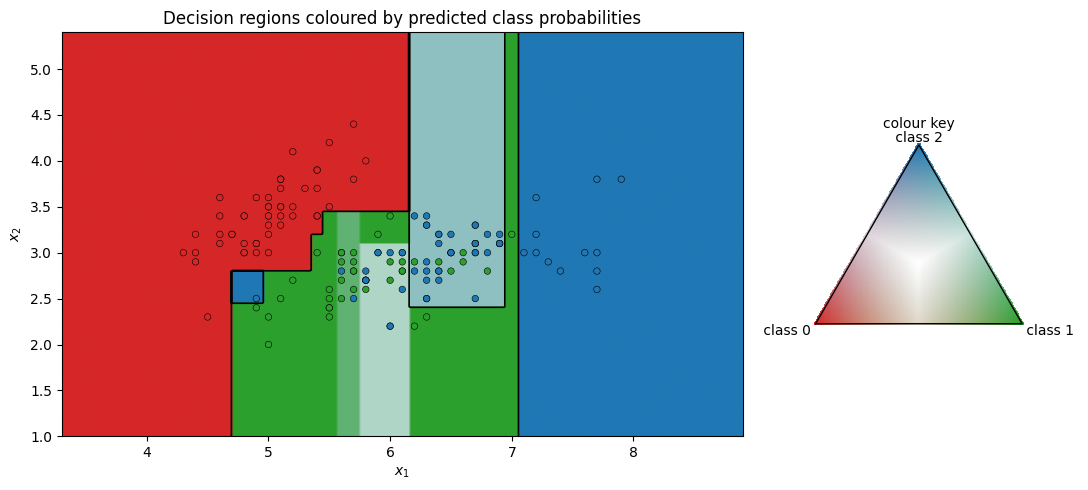

In [ ]:
fig, (ax, axL) = plt.subplots(1, 2, figsize=(11, 5),
                              gridspec_kw={"width_ratios":[3,1]})

plot_decision_regions(clf, xlim, ylim, ax=ax, cmap=cmap, n=300)

# overlay the training points using the same colour map at full confidence
onehot = np.eye(3)[y]
ax.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=cmap(onehot), edgecolors="k", linewidths=0.4, s=22)

ax.set_title("Decision regions coloured by predicted class probabilities")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

simplex_legend(ax=axL, cmap=cmap)
axL.set_title("colour key", fontsize=10)

plt.tight_layout()
plt.show()